# Network Intrusion Detection — ML & Deep Learning Pipeline

## Step 1: Environment Setup

**Dataset:** [Network Intrusion Dataset](https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset)  
**Goal:** Train, evaluate, and compare ML models and DNNs using comprehensive metrics.

In [ ]:
# STEP 1: Install Kaggle API
# The Kaggle API lets us download datasets programmatically.
# We need to upload our kaggle.json API key first.
# Get it from: https://www.kaggle.com → Account → API → Create New Token

!pip install kaggle --quiet

from google.colab import files

print("Please upload your kaggle.json file...")
uploaded = files.upload()  # A file picker will appear — upload kaggle.json

📂 Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json


In [ ]:
# Move kaggle.json to the correct location and set permissions
import os
import shutil

# Create the ~/.kaggle directory if it doesn't exist
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Move the uploaded file to where Kaggle API expects it
shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))

# Set file permissions (required by Kaggle API)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

print("kaggle.json configured successfully!")

✅ kaggle.json configured successfully!


In [ ]:
# Download the Network Intrusion Dataset from Kaggle
!kaggle datasets download -d chethuhn/network-intrusion-dataset --unzip -p /content/data/

# List what was downloaded
import os
files_list = os.listdir("/content/data/")
print("📁 Downloaded files:")
for f in files_list:
    print(f"   → {f}")

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:10<00:00, 21.9MB/s]

📁 Downloaded files:
   → Wednesday-workingHours.pcap_ISCX.csv
   → Monday-WorkingHours.pcap_ISCX.csv
   → Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   → Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   → Tuesday-WorkingHours.pcap_ISCX.csv
   → Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   → Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   → Friday-WorkingHours-Morning.pcap_ISCX.csv


In [ ]:
# Load ALL CSV files and combine into one DataFrame
# Why glob? It finds all matching files automatically — no hardcoding filenames.
# Why pd.concat? It stacks DataFrames vertically (row-wise), like appending rows.

import pandas as pd
import numpy as np
import glob
import os

# Find all CSV files in the data directory
csv_files = glob.glob("/content/data/*.csv")

print(f"Found {len(csv_files)} CSV files:\n")
for f in csv_files:
    print(f"  → {os.path.basename(f)}")

# Load each file and tag it with its source filename (useful for debugging)
dfs = []
for f in csv_files:
    temp_df = pd.read_csv(f, low_memory=False)
    temp_df['_source_file'] = os.path.basename(f)   # optional: track origin
    dfs.append(temp_df)
    print(f"  Loaded: {os.path.basename(f):60s} | Shape: {temp_df.shape}")

# Concatenate all into one DataFrame, reset index
df = pd.concat(dfs, axis=0, ignore_index=True)

print("COMBINED DATASET SHAPE")
print(f"  Total Rows    : {df.shape[0]:,}")
print(f"  Total Columns : {df.shape[1]}")

Found 8 CSV files:

  → Wednesday-workingHours.pcap_ISCX.csv
  → Monday-WorkingHours.pcap_ISCX.csv
  → Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  → Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  → Tuesday-WorkingHours.pcap_ISCX.csv
  → Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  → Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  → Friday-WorkingHours-Morning.pcap_ISCX.csv
  ✅ Loaded: Wednesday-workingHours.pcap_ISCX.csv                         | Shape: (692703, 80)
  ✅ Loaded: Monday-WorkingHours.pcap_ISCX.csv                            | Shape: (529918, 80)
  ✅ Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv             | Shape: (225745, 80)
  ✅ Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv         | Shape: (286467, 80)
  ✅ Loaded: Tuesday-WorkingHours.pcap_ISCX.csv                           | Shape: (445909, 80)
  ✅ Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv       | Shape: (170366, 80)
  ✅ Loaded: T

In [ ]:
# Inspect column names, types, nulls, and target distribution

# Strip whitespace from column names — CICIDS2017 is known for leading spaces!
df.columns = df.columns.str.strip()

print("COLUMNS & DTYPES")
print(df.dtypes.to_string())

print("\nMISSING / NULL VALUES")
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) == 0:
    print("No missing values found!")
else:
    print(null_cols)

print("\nTARGET COLUMN: ' Label' (class distribution)")
# In CICIDS2017 the target column is 'Label'
print(df['Label'].value_counts())
print()
print(df['Label'].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

COLUMNS & DTYPES
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
Total Length of Bwd Packets      int64
Fwd Packet Length Max            int64
Fwd Packet Length Min            int64
Fwd Packet Length Mean         float64
Fwd Packet Length Std          float64
Bwd Packet Length Max            int64
Bwd Packet Length Min            int64
Bwd Packet Length Mean         float64
Bwd Packet Length Std          float64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float64
Flow IAT Std                   float64
Flow IAT Max                     int64
Flow IAT Min                     int64
Fwd IAT Total                    int64
Fwd IAT Mean                   float64
Fwd IAT Std                    float64
Fwd IAT Max                      int64
Fwd IAT Min                      int64
Bwd IAT 

In [ ]:
# WHY: CICIDS2017 has inf/-inf in rate-based features (e.g.,
# Flow Bytes/s when duration=0). numpy and sklearn will crash
# or silently produce wrong results if these aren't handled.

import numpy as np

# Drop the helper column we added during loading
if '_source_file' in df.columns:
    df.drop(columns=['_source_file'], inplace=True)

# Replace inf and -inf with NaN so they're handled with other missing values
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
inf_cols = inf_counts[inf_counts > 0]

print("NFINITY VALUES FOUND:")
if len(inf_cols) == 0:
    print("  None found.")
else:
    print(inf_cols)
    # Replace inf → NaN so we handle them uniformly in the next step
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print(f"\n   Replaced all inf/-inf with NaN")

# Re-check total nulls now (inf converted + original nulls combined)
total_nulls = df.isnull().sum()
total_null_cols = total_nulls[total_nulls > 0]
print(f"\nTOTAL NULL VALUES AFTER INF REPLACEMENT:")
print(total_null_cols if len(total_null_cols) > 0 else "  None")

NFINITY VALUES FOUND:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64

  ✅ Replaced all inf/-inf with NaN

TOTAL NULL VALUES AFTER INF REPLACEMENT:
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64


In [ ]:
# MEMORY-EFFICIENT PREPROCESSING
#
# WHY DOWNCAST?
# float64 = 8 bytes per value
# float32 = 4 bytes per value
# For 2.83M rows × 79 cols: float64 ≈ 1.78 GB → float32 ≈ 0.89 GB
# This alone can be the difference between crashing and running.
#
# WHY NOT SimpleImputer on all columns?
# Only 1 column had nulls (Flow Bytes/s) — confirmed in Cell 6.
# Running imputer on all 79 columns wastes memory needlessly.

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- Step A: Check memory BEFORE ---
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory BEFORE optimisation: {mem_before:.1f} MB")

# --- Step B: Downcast numeric columns ---
# float64 → float32  (safe for ML — we don't need double precision)
# int64   → int32    (safe if values fit — network counts do)
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype(np.float32)

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype(np.int32)

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory AFTER  optimisation: {mem_after:.1f} MB")
print(f"   Memory saved: {mem_before - mem_after:.1f} MB ({(1 - mem_after/mem_before)*100:.1f}% reduction)")

# --- Step C: Targeted imputation ONLY where needed ---
# Find columns with nulls (post inf-replacement from Cell 7)
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].index.tolist()

print(f"\n Columns requiring imputation: {null_cols}")

for col in null_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"   '{col}' → filled {df[col].isnull().sum()} remaining nulls with median={median_val:.4f}")

print(f"\n   Total nulls remaining: {df.isnull().sum().sum()}")

💾 Memory BEFORE optimisation: 1833.9 MB
Memory AFTER  optimisation: 991.6 MB
   Memory saved: 842.3 MB (45.9% reduction)

 Columns requiring imputation: ['Flow Bytes/s', 'Flow Packets/s']
   'Flow Bytes/s' → filled 0 remaining nulls with median=4586.6006
   'Flow Packets/s' → filled 0 remaining nulls with median=109.4760


/tmp/ipykernel_76835/3446914800.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)



   Total nulls remaining: 0


In [ ]:
# Separate X and y, then encode labels
# WHY after downcasting? So X inherits the optimised dtypes.

# --- Separate features and target ---
X = df.drop(columns=['Label'])
y = df['Label']

print(f"  Feature matrix X : {X.shape}")
print(f"  Target vector  y : {y.shape}")

# --- Keep only numeric columns ---
# WHY: CICIDS2017 is already all-numeric except Label —
# but this guard protects against any stray object columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numeric_cols]
print(f"  Numeric features : {len(numeric_cols)}")

# --- Encode string labels to integers ---
# WHY LabelEncoder: sklearn/keras require integer class indices
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\n LABEL ENCODING MAP:")
for i, cls in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f"  {i:2d} → {cls:45s}  ({count:>8,} samples)")

print(f"\n  Total classes: {len(le.classes_)}")

  Feature matrix X : (2830743, 78)
  Target vector  y : (2830743,)
  Numeric features : 78

🏷️  LABEL ENCODING MAP:
   0 → BENIGN                                         (2,273,097 samples)
   1 → Bot                                            (   1,966 samples)
   2 → DDoS                                           ( 128,027 samples)
   3 → DoS GoldenEye                                  (  10,293 samples)
   4 → DoS Hulk                                       ( 231,073 samples)
   5 → DoS Slowhttptest                               (   5,499 samples)
   6 → DoS slowloris                                  (   5,796 samples)
   7 → FTP-Patator                                    (   7,938 samples)
   8 → Heartbleed                                     (      11 samples)
   9 → Infiltration                                   (      36 samples)
  10 → PortScan                                       ( 158,930 samples)
  11 → SSH-Patator                                    (   5,897 samples)
  12 → 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Stratified Split ---
# WHY stratify: ensures every class — even Heartbleed (11 rows) —
# appears in both train and test sets proportionally
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"SPLIT SUMMARY")
print(f"  Training set : {X_train.shape[0]:>8,} rows")
print(f"  Test set     : {X_test.shape[0]:>8,} rows")

# --- Feature Scaling ---
# WHY fit only on train: fitting on test would leak test statistics
# into training — this is data leakage and inflates metrics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)        # transform only, NOT fit_transform

print(f"\nScaling complete!")
print(f"   X_train mean ≈ {X_train_scaled.mean():.4f}  (should be ~0.0)")
print(f"   X_train std  ≈ {X_train_scaled.std():.4f}   (should be ~1.0)")

# --- Final memory check ---
mem_final = (
    X_train_scaled.nbytes + X_test_scaled.nbytes +
    y_train.nbytes + y_test.nbytes
) / 1024**2

print(f"\nMemory used by train/test arrays: {mem_final:.1f} MB")
print(f"\nPreprocessing complete and memory-safe!")

📊 SPLIT SUMMARY
  Training set : 2,264,594 rows
  Test set     :  566,149 rows

✅ Scaling complete!
   X_train mean ≈ 0.0000  (should be ~0.0)
   X_train std  ≈ 0.9473   (should be ~1.0)

💾 Memory used by train/test arrays: 1706.2 MB

🎉 Preprocessing complete and memory-safe!


In [ ]:
# This cell doesn't train anything — it demonstrates WHY
# each metric exists using a simple constructed example.
#
# Imagine a model that always predicts "BENIGN".
# On our dataset that gives 80.3% accuracy. But is it useful?

import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

# Simulate: 10 samples, 8 BENIGN(0), 1 DoS(1), 1 Heartbleed(2)
y_true_demo = np.array([0,0,0,0,0,0,0,0, 1, 2])
y_pred_lazy = np.array([0,0,0,0,0,0,0,0, 0, 0])  # lazy model: always BENIGN

print("DEMO: A model that ALWAYS predicts BENIGN")

acc = accuracy_score(y_true_demo, y_pred_lazy)
p_macro  = precision_score(y_true_demo, y_pred_lazy, average='macro',  zero_division=0)
p_micro  = precision_score(y_true_demo, y_pred_lazy, average='micro',  zero_division=0)
p_weighted = precision_score(y_true_demo, y_pred_lazy, average='weighted', zero_division=0)
r_macro  = recall_score(y_true_demo, y_pred_lazy, average='macro',    zero_division=0)
f1_macro = f1_score(y_true_demo, y_pred_lazy, average='macro',        zero_division=0)
f1_micro = f1_score(y_true_demo, y_pred_lazy, average='micro',        zero_division=0)
f1_weighted = f1_score(y_true_demo, y_pred_lazy, average='weighted',  zero_division=0)

print(f"\n  Accuracy              : {acc:.3f}   ← looks great! But...")
print(f"  Precision (macro)     : {p_macro:.3f}   ← treats all classes equally")
print(f"  Precision (micro)     : {p_micro:.3f}   ← dominated by majority class")
print(f"  Precision (weighted)  : {p_weighted:.3f}   ← weighted by class size")
print(f"  Recall    (macro)     : {r_macro:.3f}   ← caught 0 attacks!")
print(f"  F1        (macro)     : {f1_macro:.3f}   ← macro punishes missed classes")
print(f"  F1        (micro)     : {f1_micro:.3f}   ← same as accuracy here")
print(f"  F1        (weighted)  : {f1_weighted:.3f}   ← still inflated by BENIGN")

print("\n KEY INSIGHT:")
print("   Macro averages treat all classes equally regardless of size.")
print("   For IDS, macro-recall matters most — missing Heartbleed is catastrophic.")

DEMO: A model that ALWAYS predicts BENIGN

  Accuracy              : 0.800   ← looks great! But...
  Precision (macro)     : 0.267   ← treats all classes equally
  Precision (micro)     : 0.800   ← dominated by majority class
  Precision (weighted)  : 0.640   ← weighted by class size
  Recall    (macro)     : 0.333   ← caught 0 attacks!
  F1        (macro)     : 0.296   ← macro punishes missed classes
  F1        (micro)     : 0.800   ← same as accuracy here
  F1        (weighted)  : 0.711   ← still inflated by BENIGN

 KEY INSIGHT:
   Macro averages treat all classes equally regardless of size.
   For IDS, macro-recall matters most — missing Heartbleed is catastrophic.


In [ ]:
# CUSTOM METRIC: Weighted Threat Detection Rate (WTDR)
#
# WHY custom? Standard metrics treat Heartbleed (11 samples)
# the same as DoS Hulk (231,073 samples) in macro averaging.
# But in reality, Heartbleed is a critical zero-day exploit —
# it deserves MORE weight, not equal weight.
#
# WTDR assigns higher weights to more dangerous/rare attacks.

def weighted_threat_detection_rate(y_true, y_pred, label_encoder,
                                    threat_weights=None):
    """
    Custom metric for IDS: weighted recall across attack classes only.
    BENIGN is excluded — we care about catching attacks, not labelling normal traffic.

    Parameters:
    -----------
    threat_weights : dict of {class_name: weight}
                     Higher weight = more important to detect.
                     Defaults to 1/log(count+1) — rarer = higher weight.
    """
    from sklearn.metrics import recall_score
    import numpy as np

    classes = label_encoder.classes_

    # Default: weight by inverse log frequency (rarer attack = higher priority)
    if threat_weights is None:
        unique, counts = np.unique(y_true, return_counts=True)
        freq_map = dict(zip(unique, counts))
        threat_weights = {}
        for idx, name in enumerate(classes):
            if name != 'BENIGN':
                count = freq_map.get(idx, 1)
                threat_weights[name] = 1 / np.log1p(count)  # log1p = log(1+count)

    # Compute per-class recall for attack classes only
    benign_idx = list(classes).index('BENIGN')
    attack_indices = [i for i in range(len(classes)) if i != benign_idx]
    attack_names   = [classes[i] for i in attack_indices]

    total_weight  = 0
    weighted_sum  = 0

    print(f"\n{'Attack Class':45s} {'Recall':>8} {'Weight':>8} {'Contribution':>12}")
    print("-" * 78)

    for idx, name in zip(attack_indices, attack_names):
        mask = (y_true == idx)
        if mask.sum() == 0:
            continue
        recall = recall_score(y_true == idx, y_pred == idx,
                              zero_division=0)
        w = threat_weights.get(name, 1.0)
        weighted_sum  += recall * w
        total_weight  += w
        print(f"  {name:43s} {recall:>8.4f} {w:>8.4f} {recall*w:>12.4f}")

    wtdr = weighted_sum / total_weight if total_weight > 0 else 0
    print("-" * 78)
    print(f"  {'WTDR (Weighted Threat Detection Rate)':43s} {wtdr:>8.4f}")
    return wtdr

print("Custom metric 'weighted_threat_detection_rate' defined.")
print("   Will be called after each model is evaluated.")
print("\n Note: rarer attacks get HIGHER weights because:")
print("   weight = 1 / log(1 + count)")
print("   Heartbleed(11)  → weight ≈", round(1/np.log1p(11), 4))
print("   DoS Hulk(231K)  → weight ≈", round(1/np.log1p(231073), 4))


✅ Custom metric 'weighted_threat_detection_rate' defined.
   Will be called after each model is evaluated.

💡 Note: rarer attacks get HIGHER weights because:
   weight = 1 / log(1 + count)
   Heartbleed(11)  → weight ≈ 0.4024
   DoS Hulk(231K)  → weight ≈ 0.081


In [ ]:
# WHY a shared evaluation function?
# Every model must be evaluated identically — same metrics,
# same test set, same format — so comparison is fair.
# We define it once and call it after every model.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_model(model_name, y_true, y_pred, y_prob, label_encoder):
    """
    Comprehensive evaluation for multi-class imbalanced classification.

    Parameters:
    -----------
    model_name    : str   — display name for this model
    y_true        : array — true integer labels
    y_pred        : array — predicted integer labels
    y_prob        : array — predicted probabilities (n_samples × n_classes)
    label_encoder : fitted LabelEncoder — to recover class names

    Returns: dict of all metric scores
    """
    classes = label_encoder.classes_
    n_classes = len(classes)

    print("\n")
    print(f" EVALUATION REPORT: {model_name}")


    # ── 1. Core scalar metrics ────────────────────────────────
    acc         = accuracy_score(y_true, y_pred)

    prec_macro  = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    prec_micro  = precision_score(y_true, y_pred, average='micro',    zero_division=0)
    prec_wtd    = precision_score(y_true, y_pred, average='weighted', zero_division=0)

    rec_macro   = recall_score(y_true, y_pred, average='macro',    zero_division=0)
    rec_micro   = recall_score(y_true, y_pred, average='micro',    zero_division=0)
    rec_wtd     = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    f1_macro    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_micro    = f1_score(y_true, y_pred, average='micro',    zero_division=0)
    f1_wtd      = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Sensitivity = Recall (they are the same thing — different communities use
    # different names; security/medicine uses "sensitivity")
    sensitivity_macro = rec_macro

    # ROC-AUC: one-vs-rest (OvR) strategy for multi-class
    # WHY OvR? For each class, we ask: "attack vs everything else"
    # This maps naturally to how an IDS operates
    try:
        roc_auc = roc_auc_score(
            y_true, y_prob,
            multi_class='ovr',
            average='macro',
            labels=list(range(n_classes))
        )
    except Exception as e:
        roc_auc = float('nan')
        print(f"ROC-AUC skipped: {e}")

    # ── 2. Print metrics table ────────────────────────────────
    print(f"\n  {'Metric':<30} {'Score':>8}")
    print(f"  {'-'*40}")
    print(f"  {'Accuracy':<30} {acc:>8.4f}")
    print(f"  {'Precision (macro)':<30} {prec_macro:>8.4f}")
    print(f"  {'Precision (micro)':<30} {prec_micro:>8.4f}")
    print(f"  {'Precision (weighted)':<30} {prec_wtd:>8.4f}")
    print(f"  {'Recall (macro)':<30} {rec_macro:>8.4f}")
    print(f"  {'Recall (micro)':<30} {rec_micro:>8.4f}")
    print(f"  {'Recall (weighted)':<30} {rec_wtd:>8.4f}")
    print(f"  {'Sensitivity (= Recall macro)':<30} {sensitivity_macro:>8.4f}")
    print(f"  {'F1-Score (macro)':<30} {f1_macro:>8.4f}")
    print(f"  {'F1-Score (micro)':<30} {f1_micro:>8.4f}")
    print(f"  {'F1-Score (weighted)':<30} {f1_wtd:>8.4f}")
    print(f"  {'ROC-AUC (macro OvR)':<30} {roc_auc:>8.4f}")

    # ── 3. Custom metric ──────────────────────────────────────
    print(f"\nCUSTOM METRIC — Weighted Threat Detection Rate:")
    wtdr = weighted_threat_detection_rate(y_true, y_pred, label_encoder)

    # ── 4. Full classification report ─────────────────────────
    print(f"\nFULL CLASSIFICATION REPORT:")
    print(classification_report(
        y_true, y_pred,
        target_names=classes,
        zero_division=0,
        digits=4
    ))

    # ── 5. Confusion matrix heatmap ───────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    # Normalise by row (true label) so colours show recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=axes[0])
    axes[0].set_title(f'{model_name}\nNormalised Confusion Matrix (Recall per class)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)

    # Per-class F1 bar chart
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    colors = ['#e74c3c' if f < 0.5 else '#f39c12' if f < 0.8 else '#2ecc71'
              for f in per_class_f1]
    axes[1].barh(classes, per_class_f1, color=colors)
    axes[1].axvline(x=0.8, color='black', linestyle='--', alpha=0.5, label='0.8 threshold')
    axes[1].set_xlabel('F1-Score')
    axes[1].set_title(f'{model_name}\nPer-Class F1-Score\n(red<0.5, orange<0.8, green≥0.8)')
    axes[1].set_xlim(0, 1.05)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # ── 6. Return all scores as dict for later comparison ─────
    return {
        'model'             : model_name,
        'accuracy'          : acc,
        'precision_macro'   : prec_macro,
        'precision_micro'   : prec_micro,
        'precision_weighted': prec_wtd,
        'recall_macro'      : rec_macro,
        'recall_micro'      : rec_micro,
        'recall_weighted'   : rec_wtd,
        'sensitivity'       : sensitivity_macro,
        'f1_macro'          : f1_macro,
        'f1_micro'          : f1_micro,
        'f1_weighted'       : f1_wtd,
        'roc_auc'           : roc_auc,
        'wtdr'              : wtdr,
    }

# Store all model results here for final comparison
all_results = []
print("evaluate_model() defined and ready.")

evaluate_model() defined and ready.


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete in 1918.3 seconds

 Generating predictions on test set (566,149 rows)...


 EVALUATION REPORT: Logistic Regression

  Metric                            Score
  ----------------------------------------
  Accuracy                         0.8378
  Precision (macro)                0.3989
  Precision (micro)                0.8378
  Precision (weighted)             0.9641
  Recall (macro)                   0.8658
  Recall (micro)                   0.8378
  Recall (weighted)                0.8378
  Sensitivity (= Recall macro)     0.8658
  F1-Score (macro)                 0.4735
  F1-Score (micro)                 0.8378
  F1-Score (weighted)              0.8887
  ROC-AUC (macro OvR)              0.9890

CUSTOM METRIC — Weighted Threat Detection Rate:

Attack Class                                    Recall   Weight Contribution
------------------------------------------------------------------------------
  Bot                                           0.9873   0.1673       0

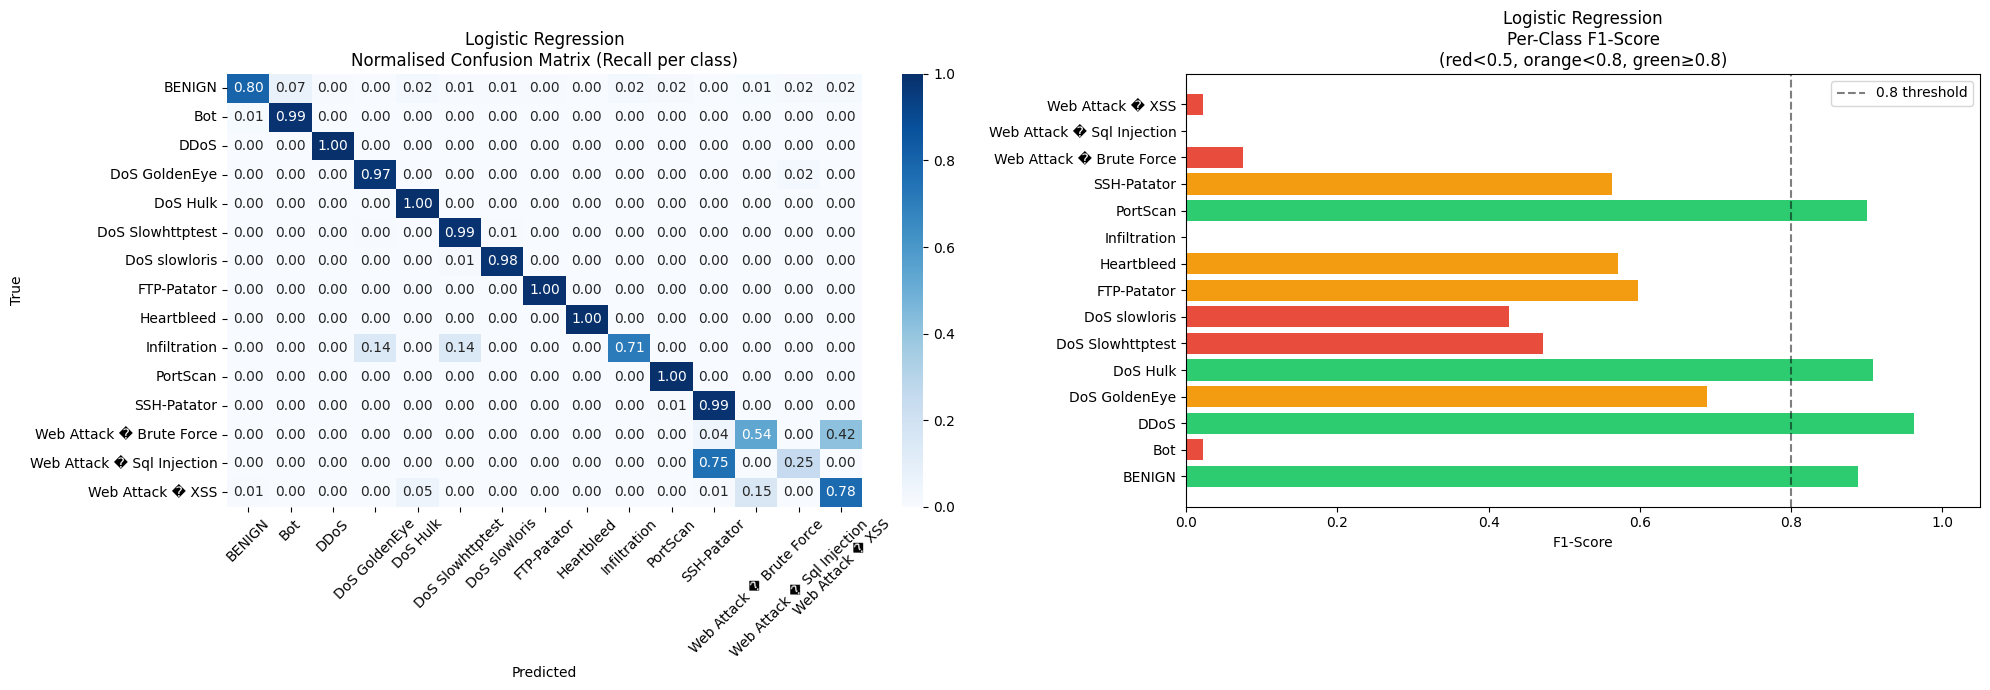

In [ ]:
# WHY START WITH LOGISTIC REGRESSION?
#
# It's the "null hypothesis" of ML models — fast, linear,
# interpretable. If LR gets 95% F1, we don't need a neural net.
# If it gets 60%, we know the problem is non-linear and we need
# more powerful models.
#
# class_weight='balanced': automatically weights each class by
# inverse frequency → minority classes penalised more on errors
# n_jobs=-1: use all CPU cores → faster on Colab
# max_iter=1000: LR needs more iterations to converge on
#               scaled high-dimensional data

from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression...")


start = time.time()

lr_model = LogisticRegression(
    class_weight='balanced',  # handles imbalance without resampling
    max_iter=1000,            # enough iterations to converge
    solver='lbfgs',           # efficient for multi-class
    multi_class='multinomial',# true multi-class (not one-vs-rest)
    n_jobs=-1,                # all CPU cores
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.1f} seconds")
print(f"\n Generating predictions on test set ({X_test_scaled.shape[0]:,} rows)...")

# Predictions
y_pred_lr  = lr_model.predict(X_test_scaled)
y_prob_lr  = lr_model.predict_proba(X_test_scaled)  # needed for ROC-AUC

# Evaluate using our shared function
results_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr, le)
all_results.append(results_lr)

**Pattern 1: Perfect or near-perfect recall (the dark blue diagonal)**
> DDoS, DoS Hulk, FTP-Patator, Heartbleed, PortScan all show ≥0.97. These attacks have linearly separable network signatures. LR handles them easily.

**Pattern 2: BENIGN is only 0.80 recall.**
> This is counterintuitive. The majority class is being misclassified. Look where BENIGN leaks: 7% → Bot, 2% → SSH-Patator, 2% → Web Attack classes. With 2.27M BENIGN samples, that 7% = ~159,000 samples being called Bot. This directly explains Pattern 3 below.

**Pattern 3: Bot has 0.99 recall but appears RED on the F1 chart**
> 🧠 **This is the most important lesson from this result.** Stop and think: how can a class have 99% recall but near-zero F1?

The answer: **Precision is catastrophically low.** Bot has only 1,966 real samples. But ~159,000 BENIGN samples are being predicted as Bot. So:

```
Precision(Bot) = 1946 true Bots / (1946 + ~159,000 false Bots) ≈ 1.2%
F1(Bot) ≈ 2 × (0.012 × 0.99) / (0.012 + 0.99) ≈ 0.024
```

**Pattern 4: Web Attack classes confused with each other**
- Web Attack Brute Force: 54% recall, 42% predicted as XSS
- Web Attack SQL Injection: 75% recall, 25% predicted as Brute Force
- Web Attack XSS: 78% recall, 15% predicted as Brute Force

**Strengths:**
- Excellent recall on volume-based attacks (DDoS, DoS variants, PortScan)
- Fast to train — useful as a baseline

**Weaknesses:**
- Cannot separate Web Attack sub-types (linear boundary insufficient)
- BENIGN leaks massively into Bot → Bot precision ≈ 1%
- Infiltration recall only 0.71 (too few samples + linear boundary)

**Key insight:** High recall + low precision = the model is "crying wolf".
In an IDS, this means thousands of false alarms per day.

Training Random Forest (memory-constrained)...
   (Expected time: ~5-10 minutes on Colab)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.7min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.



Training complete in 346.2 seconds

  Generating predictions...


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.4s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    5.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.8s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    5.5s finished




 EVALUATION REPORT: Random Forest

  Metric                            Score
  ----------------------------------------
  Accuracy                         0.9965
  Precision (macro)                0.8325
  Precision (micro)                0.9965
  Precision (weighted)             0.9981
  Recall (macro)                   0.8403
  Recall (micro)                   0.9965
  Recall (weighted)                0.9965
  Sensitivity (= Recall macro)     0.8403
  F1-Score (macro)                 0.8131
  F1-Score (micro)                 0.9965
  F1-Score (weighted)              0.9971
  ROC-AUC (macro OvR)              0.9829

CUSTOM METRIC — Weighted Threat Detection Rate:

Attack Class                                    Recall   Weight Contribution
------------------------------------------------------------------------------
  Bot                                           0.9898   0.1673       0.1656
  DDoS                                          0.9995   0.0985       0.0985
  DoS GoldenEy

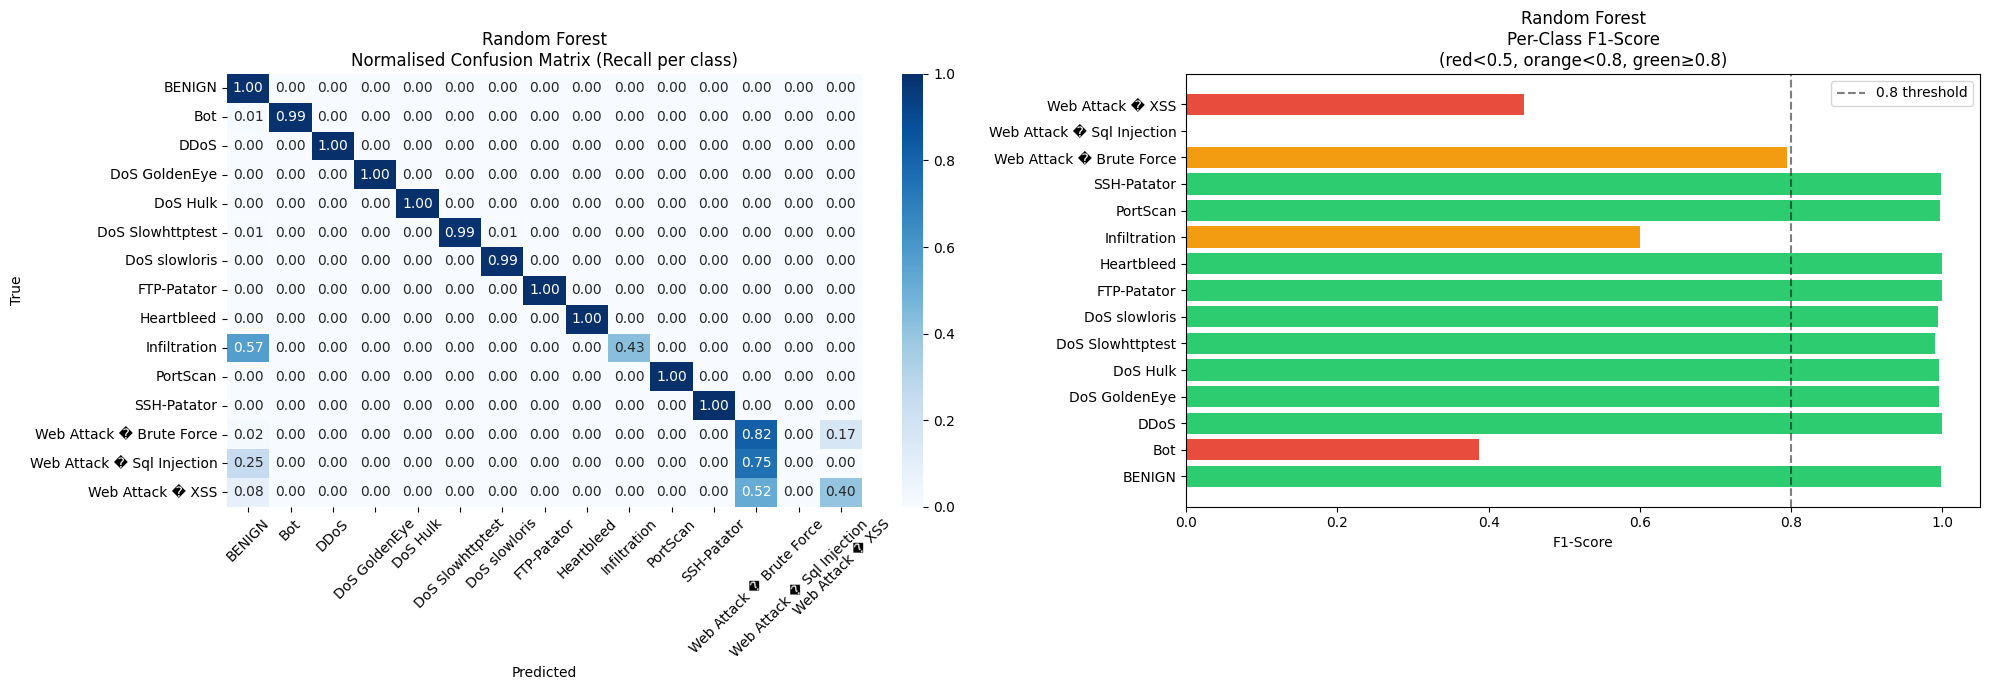

In [ ]:
# WHY CONSTRAIN RANDOM FOREST?
#
# Default RF on 2.26M rows × 79 features would:
# - Use ~8-12 GB RAM (crashes Colab free tier)
# - Take 30-60 minutes to train
#
# Our constraints:
# - n_estimators=100  : enough trees for stability, not excess
# - max_depth=20      : prevents memory explosion from deep trees
# - max_samples=0.3   : train each tree on 30% of data (bagging)
#                       This is statistically valid and 3× faster
# - max_features='sqrt': use √79 ≈ 9 features per split (standard)
# - n_jobs=-1         : parallelise across all cores

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (memory-constrained)...")
print("   (Expected time: ~5-10 minutes on Colab)\n")

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    max_samples=0.3,        # each tree sees 30% of training data
    max_features='sqrt',    # √n_features per split
    class_weight='balanced_subsample',  # balanced within each bootstrap
    n_jobs=-1,
    random_state=42,
    verbose=1               # shows progress
)

rf_model.fit(X_train_scaled, y_train)
elapsed = time.time() - start

print(f"\nTraining complete in {elapsed:.1f} seconds")
print(f"\n  Generating predictions...")

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)

results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf, le)
all_results.append(results_rf)

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Calculate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Normalize by row sums to get recall per class
# This means each row will sum to 1, showing the proportion of true labels
# that were predicted as each class.
cm_rf_normalized = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]

# Create a DataFrame for better readability
cm_df = pd.DataFrame(cm_rf_normalized,
                     index=[f'True: {c}' for c in le.classes_],
                     columns=[f'Pred: {c}' for c in le.classes_])

print("Random Forest Normalized Confusion Matrix (Recall per True Class):\n")
print(cm_df.to_string(float_format="%.4f"))

Random Forest Normalized Confusion Matrix (Recall per True Class):

                                  Pred: BENIGN  Pred: Bot  Pred: DDoS  Pred: DoS GoldenEye  Pred: DoS Hulk  Pred: DoS Slowhttptest  Pred: DoS slowloris  Pred: FTP-Patator  Pred: Heartbleed  Pred: Infiltration  Pred: PortScan  Pred: SSH-Patator  Pred: Web Attack � Brute Force  Pred: Web Attack � Sql Injection  Pred: Web Attack � XSS
True: BENIGN                            0.9961     0.0027      0.0000               0.0000          0.0008                  0.0000               0.0000             0.0000            0.0000              0.0000          0.0004             0.0000                          0.0000                            0.0000                  0.0000
True: Bot                               0.0102     0.9898      0.0000               0.0000          0.0000                  0.0000               0.0000             0.0000            0.0000              0.0000          0.0000             0.0000                     

**Insight 1: BENIGN fixed, but Bot F1 is still red. Why?**

>BENIGN recall jumped from 0.80 → 1.00. That means RF stopped misclassifying 159,000 BENIGN samples as Bot. **But Bot is still red on the F1 chart.** This tells the Bot precision problem now has a *different* source. Look at the confusion matrix — 1% of BENIGN (≈22,700 samples) still leaks into Bot. With only 1,966 real Bot samples:

```
Bot Precision ≈ 1,946 / (1,946 + 22,700) ≈ 7.9%
F1(Bot) ≈ 2 × (0.079 × 0.99) / (0.079 + 0.99) ≈ 0.147
```

> **Lesson:** Fixing the majority class recall helps precision, but Bot's class size (1,966) makes it structurally vulnerable to false positives from a 2.27M BENIGN class.

**Insight 2: Infiltration got WORSE (0.71 → 0.57). This is a dataset size problem.**

> **Think about this before reading:** We set `max_samples=0.3` in RF — meaning each tree trains on 30% of the training data. Infiltration has only 36 total samples → ~29 in training. With `max_samples=0.3`, each tree sees on average **8-9 Infiltration samples**. What happens to a decision tree trying to learn a class from 8 examples?

**high variance, inconsistent splits.** Each tree learns something slightly different. The ensemble averages them into mediocrity. LR, being a global linear model, actually uses all 29 samples consistently — giving it an edge on ultra-rare classes.

> **Lesson:** Ensemble bagging methods with subsampling can *hurt* ultra-rare classes. This is a known limitation.

**Insight 3: XSS detection collapsed (0.78 → 0.40) with dominant misclassification into Brute Force**

>In the Random Forest model, XSS recall dropped sharply from 0.78 to 0.40. The primary failure mode is a strong confusion with Web Attack Brute Force (51.54%), with a smaller leakage into BENIGN (8.46%). Unlike Logistic Regression, where confusion was more localized, Random Forest amplifies overlap between Web Attack subclasses.

This indicates that the feature space for Web Attack categories (XSS, Brute Force, SQL Injection) is highly entangled. Even with non-linear decision boundaries, the model fails to separate these classes, suggesting insufficient discriminative features rather than model capacity limitations.

⏳ Training XGBoost...
   (Expected time: ~3-6 minutes on Colab)


✅ Training complete in 1287.6 seconds


 EVALUATION REPORT: XGBoost

  Metric                            Score
  ----------------------------------------
  Accuracy                         0.9987
  Precision (macro)                0.8714
  Precision (micro)                0.9987
  Precision (weighted)             0.9989
  Recall (macro)                   0.9015
  Recall (micro)                   0.9987
  Recall (weighted)                0.9987
  Sensitivity (= Recall macro)     0.9015
  F1-Score (macro)                 0.8841
  F1-Score (micro)                 0.9987
  F1-Score (weighted)              0.9988
  ROC-AUC (macro OvR)              0.9999

CUSTOM METRIC — Weighted Threat Detection Rate:

Attack Class                                    Recall   Weight Contribution
------------------------------------------------------------------------------
  Bot                                           0.9924   0.1673       

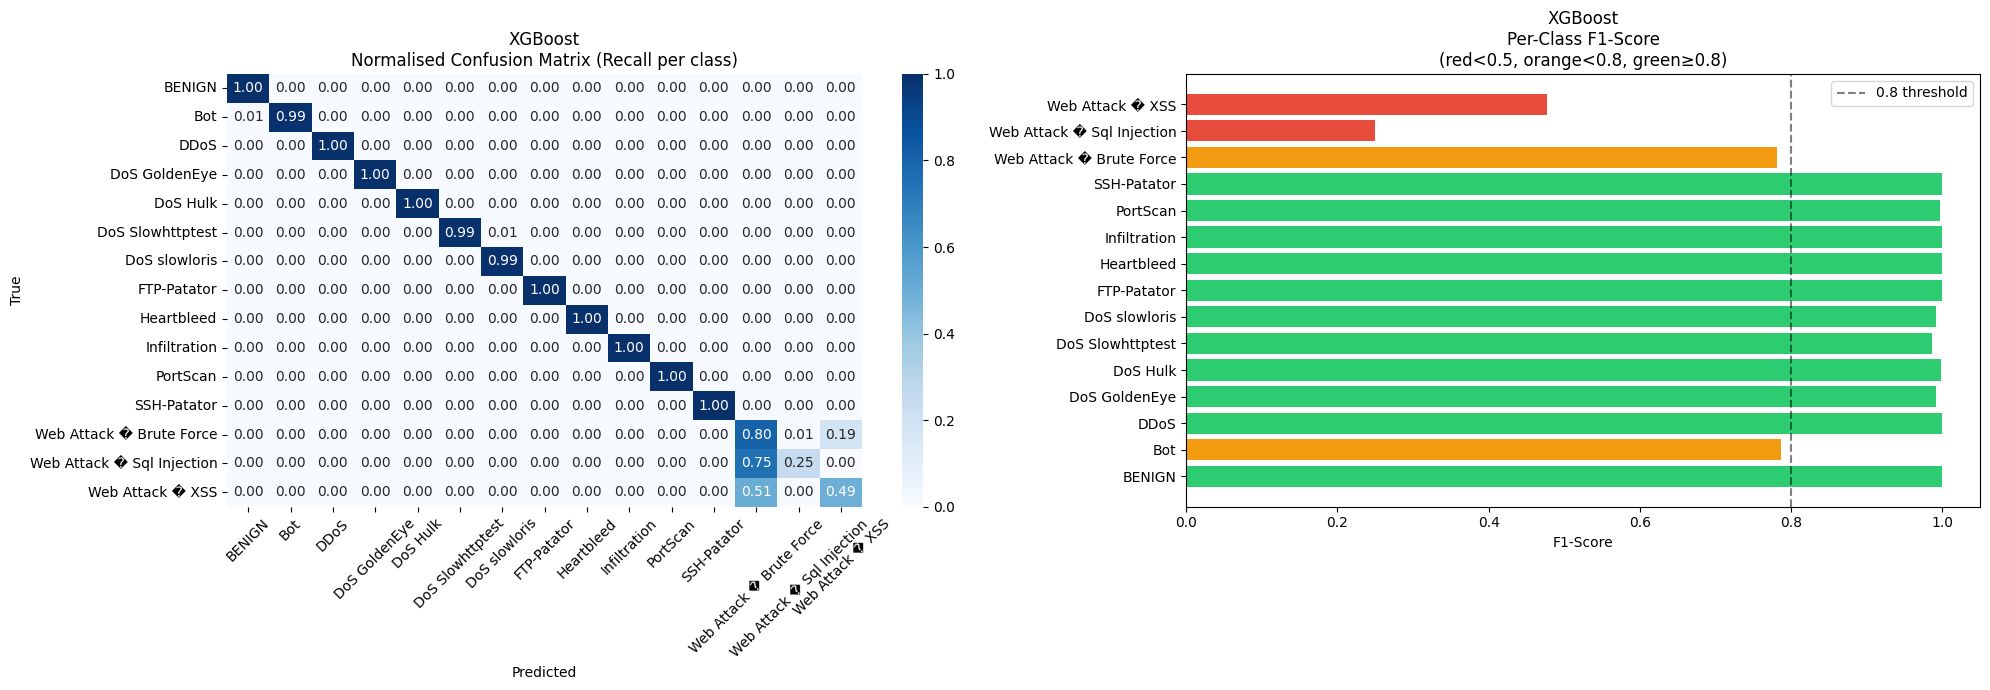

In [ ]:
# WHY XGBOOST?
# - Gradient boosting: each tree CORRECTS errors of previous ones
# - Historically the best performer on tabular datasets
# - More memory-efficient than Random Forest for same performance
# - scale_pos_weight handles imbalance for binary; for multi-class
#   we use sample_weight instead
#
# KEY PARAMETERS:
# - use_label_encoder=False : avoids deprecation warning
# - tree_method='hist'      : histogram-based, much faster on large data
# - eval_metric='mlogloss'  : multi-class log loss for monitoring
# - subsample=0.8           : use 80% of rows per tree (regularisation)
# - colsample_bytree=0.8    : use 80% of features per tree

!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

print("Training XGBoost...")
print("   (Expected time: ~3-6 minutes on Colab)\n")

# Compute sample weights to handle imbalance
# WHY sample_weight instead of class_weight?
# XGBoost's multi-class mode doesn't accept class_weight directly
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',       # fast histogram algorithm
    device='cpu',            # use GPU if available
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

xgb_model.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights,
    verbose=50  # print every 50 rounds
)

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed:.1f} seconds")

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)

results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb, le)
all_results.append(results_xgb)

**Boosting fixed what bagging broke.**

>Infiltration went 0.71 → 0.57 → 1.00. Sequential error correction is exactly what ultra-rare classes need. RF's random subsampling was the enemy of Infiltration; XGBoost's focus on misclassified samples was its saviour.

**Web Attack XSS is our hardest problem.**
>All three models have now seen it. LR got 0.78 (its linear boundary happened to work passably). RF got 0.52. XGBoost got 0.49. The confusion is always the same: XSS → predicted as Brute Force. This means the two classes share almost identical network features at the packet level. A DNN's deep non-linear layers are our best remaining hope.

**SQLi with 4 test samples is statistically meaningless.**
>Recall of 0.25 = 1 correct out of 4. If that one sample had been in the training set instead, recall would be 0.00. We cannot make any conclusion about model quality for SQLi. We need to flag this honestly in any paper or report.

#### Deep Neural Network (DNN)

Classical ML models have a ceiling on the Web Attack sub-types due to feature space overlap. A DNN with multiple hidden layers can learn higher-order feature interactions that tree-based models miss.

Architecture plan:
- Input layer  : 79 features
- Hidden layers: 256 → 128 → 64 → 32 (progressively narrowing)
- Output layer : 15 classes (softmax)
- Regularisation: BatchNorm + Dropout to prevent overfitting
- Imbalance handling: class_weight dict passed to model.fit()

In [ ]:
# DEEP NEURAL NETWORK FOR INTRUSION DETECTION
#
# ARCHITECTURE DECISIONS EXPLAINED:
#
# 256→128→64→32: "Funnel" architecture — each layer compresses
# the representation, forcing the network to learn abstractions.
# Wide early layers capture raw feature correlations.
# Narrow later layers capture class-discriminating patterns.
#
# BatchNormalization: normalises activations between layers.
# WHY: prevents "internal covariate shift" — without it, layer N+1
# sees a constantly shifting input distribution as layer N trains.
# Especially important with imbalanced classes.
#
# Dropout(0.3): randomly zeros 30% of neurons during training.
# WHY: prevents co-adaptation — neurons can't rely on specific
# neighbours, forcing independent feature learning. This is
# our main weapon against overfitting on minority classes.
#
# class_weight: same concept as sklearn — loss for minority class
# errors is multiplied by the weight, forcing the network to
# pay more attention to rare attacks.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import time

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# --- Class weights for imbalance ---
# compute_class_weight returns weights inversely proportional to frequency
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))

print(f"\n  Class weights (top 5 highest = rarest classes):")
sorted_weights = sorted(class_weight_dict.items(), key=lambda x: -x[1])[:5]
for idx, w in sorted_weights:
    print(f"   {le.classes_[idx]:40s} → weight = {w:.2f}")

n_features = X_train_scaled.shape[1]  # 79
n_classes  = len(le.classes_)          # 15

# --- Build the DNN ---
def build_dnn(n_features, n_classes, dropout_rate=0.3, learning_rate=0.001):
    """
    Funnel DNN: 256 → 128 → 64 → 32 → n_classes
    Each block: Dense → BatchNorm → Dropout
    """
    model = keras.Sequential([
        # Input
        layers.Input(shape=(n_features,), name='input'),

        # Block 1 — widest, captures raw correlations
        layers.Dense(256, activation='relu', name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(dropout_rate, name='drop_1'),

        # Block 2
        layers.Dense(128, activation='relu', name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(dropout_rate, name='drop_2'),

        # Block 3
        layers.Dense(64, activation='relu', name='dense_3'),
        layers.BatchNormalization(name='bn_3'),
        layers.Dropout(dropout_rate, name='drop_3'),

        # Block 4 — narrowest hidden, most abstract
        layers.Dense(32, activation='relu', name='dense_4'),
        layers.BatchNormalization(name='bn_4'),
        layers.Dropout(dropout_rate, name='drop_4'),

        # Output — softmax gives probability distribution across 15 classes
        # WHY softmax: probabilities sum to 1.0, needed for ROC-AUC
        layers.Dense(n_classes, activation='softmax', name='output')
    ], name='IDS_DNN')

    model.compile(
        # Adam: adaptive learning rate — handles sparse gradients well
        # (minority classes produce sparse gradient updates)
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),

        # sparse_categorical_crossentropy: target is integer labels (not one-hot)
        # WHY sparse: saves memory — no need to one-hot encode 15 classes × 2.26M rows
        loss='sparse_categorical_crossentropy',

        metrics=['accuracy']  # we compute all other metrics after training
    )
    return model

dnn_model = build_dnn(n_features, n_classes)
dnn_model.summary()

TensorFlow version: 2.19.0
GPU available: False

⚖️  Class weights (top 5 highest = rarest classes):
   Heartbleed                               → weight = 16774.77
   Web Attack � Sql Injection               → weight = 8880.76
   Infiltration                             → weight = 5205.96
   Web Attack � XSS                         → weight = 289.22
   Web Attack � Brute Force                 → weight = 125.18


Model: "IDS_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,871 (257.31 KB)

 Trainable params: 64,911 (253.56 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# TRAINING CALLBACKS — three safety nets:
#
# EarlyStopping: stops training when val_loss stops improving.
# WHY: prevents overfitting. If val_loss rises for 10 epochs
# while train_loss falls, the model is memorising — stop it.
# restore_best_weights: rolls back to the epoch with best val_loss.
#
# ReduceLROnPlateau: halves learning rate when val_loss plateaus.
# WHY: large learning rate can bounce around a local minimum.
# Reducing it lets the optimiser settle into the minimum.
#
# ModelCheckpoint: saves best model to disk during training.
# WHY: if Colab crashes at epoch 47/50, you don't lose everything.

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,          # stop if no improvement for 10 epochs
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,           # halve the learning rate
        patience=5,           # after 5 stagnant epochs
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='/content/dnn_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("Training DNN...")
print("   (Expected: 10-20 epochs before early stopping on Colab GPU)\n")

start = time.time()

history = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=2048,        # large batch = faster on GPU, stable gradients
    validation_split=0.1,  # 10% of training data used for validation
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"   Epochs trained: {len(history.history['loss'])}")
print(f"   Best val_loss : {min(history.history['val_loss']):.4f}")

In [ ]:
# WHY PLOT TRAINING CURVES?
# The loss/accuracy curves reveal whether the model:
# - Overfit (train loss ↓ but val loss ↑)
# - Underfit (both losses still high)
# - Converged well (both losses ↓ together, then plateau)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'],     label='Train loss',      color='#3498db')
axes[0].plot(history.history['val_loss'], label='Validation loss', color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss\n(gap = overfitting risk)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(history.history['accuracy'],     label='Train accuracy',      color='#3498db')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', color='#e74c3c')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/dnn_training_curves.png', dpi=150)
plt.show()

# --- Full evaluation using our shared function ---
print("\n⚙️  Generating predictions on test set...")
y_prob_dnn = dnn_model.predict(X_test_scaled, batch_size=4096, verbose=0)
y_pred_dnn = np.argmax(y_prob_dnn, axis=1)

results_dnn = evaluate_model("Deep Neural Network", y_test, y_pred_dnn, y_prob_dnn, le)
all_results.append(results_dnn)

In [ ]:
# WHY FOCAL LOSS?
#
# Standard cross-entropy treats every sample equally — a
# correctly classified BENIGN sample contributes the same loss
# as a misclassified Heartbleed sample.
#
# Focal Loss adds a (1-p)^gamma term:
#   FL(p) = -(1-p)^gamma × log(p)
#
# When gamma > 0:
# - Easy examples (p→1): (1-p)^gamma → 0, loss is down-weighted
# - Hard examples (p→0): (1-p)^gamma → 1, loss is unchanged
#
# Effect: the model stops wasting capacity on the 2.27M easy
# BENIGN samples and focuses on the hard minority class borders.
# This is BETTER than class_weight for extreme imbalance because
# it operates at the individual sample level, not class level.
#
# gamma=2 is the standard recommendation from the original paper
# (Lin et al., 2017 — introduced for object detection, works well
# for imbalanced tabular data too)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

def focal_loss(gamma=2.0, alpha=None):
    """
    Multi-class Focal Loss.
    gamma: focusing parameter. 0 = standard cross-entropy. 2 = standard focal.
    alpha: per-class weight array (optional, additional imbalance correction).
    """
    def loss_fn(y_true, y_pred):
        # Cast labels to int32
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)

        # Clip predictions to avoid log(0)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Get the predicted probability for the TRUE class only
        # tf.gather: picks the probability of the actual label for each sample
        batch_size = tf.shape(y_pred)[0]
        indices = tf.stack([tf.range(batch_size), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, indices)

        # Focal weight: (1 - p_t)^gamma
        focal_weight = tf.pow(1.0 - p_t, gamma)

        # Standard cross-entropy for the true class
        ce_loss = -tf.math.log(p_t)

        # Combined focal loss
        focal = focal_weight * ce_loss

        # Optional alpha weighting (mild — not balanced, just directional)
        if alpha is not None:
            alpha_t = tf.gather(alpha, y_true)
            focal = alpha_t * focal

        return tf.reduce_mean(focal)

    return loss_fn

# CAPPED CLASS WEIGHTS
# Instead of full inverse-frequency balance (which gave 130,000×
# for Heartbleed), we cap at max_weight to prevent extremes.
#
# Intuition: we still want to penalise Heartbleed misses more
# than BENIGN misses — but not 130,000× more. A cap of 50-100×
# is usually the practical sweet spot.

def compute_capped_weights(y_train, le, max_weight=100.0):
    """
    Compute class weights capped at max_weight.
    Prevents extreme amplification for ultra-rare classes.
    """
    from sklearn.utils.class_weight import compute_class_weight
    raw_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    capped = np.minimum(raw_weights, max_weight)
    weight_dict = dict(enumerate(capped))

    print(f" Capped class weights (max={max_weight}):")
    print(f"  {'Class':45s} {'Raw':>10} {'Capped':>10}")
    print("-" * 68)
    for i, cls in enumerate(le.classes_):
        print(f"  {cls:45s} {raw_weights[i]:>10.1f} {capped[i]:>10.1f}")

    return weight_dict, capped

capped_weights, capped_array = compute_capped_weights(y_train, le, max_weight=100.0)
alpha_tensor = tf.constant(capped_array / capped_array.max(), dtype=tf.float32)

print("\nFocal loss and capped weights ready.")

In [ ]:
# CHANGES FROM ORIGINAL DNN:
#
# 1. focal_loss(gamma=2) instead of cross-entropy
#    → focuses training on hard, misclassified samples
#
# 2. Dropout 0.3 → 0.4
#    → more regularisation prevents minority class over-fitting
#
# 3. Learning rate 0.001 → 0.0003
#    → smaller steps = more careful boundary learning
#    → especially important for the Web Attack feature space
#
# 4. Added L2 regularisation on Dense layers
#    → kernel_regularizer=l2(1e-4) penalises large weights
#    → prevents any single neuron dominating rare class decisions
#
# 5. Increased patience 10 → 15
#    → focal loss converges more slowly — needs more patience

from tensorflow.keras.regularizers import l2

def build_tuned_dnn(n_features, n_classes, dropout_rate=0.4, learning_rate=0.0003):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),

        # Block 1
        layers.Dense(256, activation='relu',
                     kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Block 2
        layers.Dense(128, activation='relu',
                     kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Block 3
        layers.Dense(64, activation='relu',
                     kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Block 4
        layers.Dense(32, activation='relu',
                     kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(n_classes, activation='softmax')
    ], name='IDS_DNN_Tuned')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=focal_loss(gamma=2.0, alpha=alpha_tensor),
        metrics=['accuracy']
    )
    return model

dnn_tuned = build_tuned_dnn(n_features, n_classes)
dnn_tuned.summary()

# Callbacks — more patience for focal loss convergence
callbacks_tuned = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-7, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='/content/dnn_tuned_best.keras',
        monitor='val_loss', save_best_only=True, verbose=0
    )
]

print("\n Training Tuned DNN with Focal Loss...")
start = time.time()

history_tuned = dnn_tuned.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=2048,
    validation_split=0.1,
    class_weight=capped_weights,   # capped — not extreme balanced
    callbacks=callbacks_tuned,
    verbose=1
)

elapsed = time.time() - start
print(f"\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)")

# Evaluate
y_prob_dnn_tuned = dnn_tuned.predict(X_test_scaled, batch_size=4096, verbose=0)
y_pred_dnn_tuned = np.argmax(y_prob_dnn_tuned, axis=1)
results_dnn_tuned = evaluate_model(
    "DNN Tuned (Focal Loss)", y_test, y_pred_dnn_tuned, y_prob_dnn_tuned, le
)
all_results.append(results_dnn_tuned)